In [1]:
# ============================================================
# Cell 0 — Parameters
# ============================================================
"""
Parameters from Table I of:
Gioannini & Rossetti, "Time-Domain Traveling Wave Model of Quantum Dot DFB Lasers"
IEEE J. Sel. Top. Quantum Electron., Vol. 17, No. 5, 2011

All values are in SI units unless noted.
"""

import numpy as np
import os

# ── Physical constants ────────────────────────────────────────────────────────
q        = 1.602176634e-19   # elementary charge (C)
hbar     = 1.054571817e-34   # reduced Planck constant (J·s)
kB       = 1.380649e-23      # Boltzmann constant (J/K)
c0       = 2.997924580e8     # speed of light in vacuum (m/s)
eps0     = 8.854187817e-12   # vacuum permittivity (F/m)
m0       = 9.1093837015e-31  # free electron mass (kg)
T        = 300.0             # room temperature (K)

# ── Material parameters ───────────────────────────────────────────────────────
h_w      = 5e-9              # QD layer height (m)
eta      = 3.3445            # effective refractive index (dimensionless)
N_l      = 8                 # number of QD layers
N_D      = 5.9e14            # QD surface density (m⁻²)  [5.9×10¹⁰ cm⁻² → ×10⁴]
N_groups = 51                # number of QD groups for inhomogeneous broadening

# State degeneracies: D_m for m = ES2, ES1, GS
D = {
    'ES2': 6,
    'ES1': 4,
    'GS':  2,
}

hbar_Gamma = 7e-3 * q       # homogeneous linewidth (J)  [7 meV → ×q]
Gamma      = hbar_Gamma / hbar  # dephasing rate (rad/s)

Delta_E    = 38e-3 * q      # FWHM of inhomogeneous broadening (J)  [38 meV]

# Dipole matrix elements A_m  (cm³·eV → m³·J)
# 1 cm³·eV = 1e-6 m³ × 1.602e-19 J  →  multiply by 1e-6 * q
A = {
    'ES1': 1.26e-20 * 1e-6 * q,   # m³·J
    'GS':  2.03e-20 * 1e-6 * q,   # m³·J
}

# SCH diffusion/transport times (s)
tau_c_e_W  = 1.2e-12        # electron transport time across SCH (s)
tau_c_h_W  = 23.2e-12       # hole transport time across SCH (s)

tau_e_e_W  = 0.0492e-12

# Electron relaxation times τ_c^{e,m} for m = ES2, ES1, GS (s)
tau_c_e = {
    'ES2': 3e-12,
    'ES1': 2e-12,
    'GS':  2e-12,
}

tau_e_e_im = {
    'ES2': 6.15e-12,
    'ES1': 7.99e-12,
    'GS':  10.63e-12,
}

# Interband recombination time in the WL (s)
tau_r_e_W  = 100e-12

tau_e_h_qd = 1.46E-12

# Spontaneous emission recombination times τ_Sp^m for m = ES2, ES1, GS (s)
tau_Sp = {
    'ES2': 2.8e-9,
    'ES1': 2.8e-9,
    'GS':  2.8e-9,
}

# Auger recombination times τ_Au^m for m = ES2, ES1, GS (s)
tau_Au = {
    'ES2': 110e-12,
    'ES1': 275e-12,
    'GS':  660e-12,
}

# Interband transition energies hbar*omega_im for i=(N+1)/2 (central group)
# m = ES2, ES1, GS  (eV → J)
hbar_omega = {
    'ES2': 1.098 * q,   # J
    'ES1': 1.042 * q,
    'GS':  0.959 * q,   # J
}

# Reference (Bragg) angular frequency — set to GS transition of central group
omega_0 = hbar_omega['GS'] / hbar   # rad/s

# Intrinsic waveguide losses (m⁻¹)  [1.5 cm⁻¹ → ×100]
alpha_i  = 1.5e2

# ── Device parameters ─────────────────────────────────────────────────────────
W        = 2.2e-6            # ridge equivalent width (m)
h_SCH    = 430e-9            # SCH height (m)
r0_sq    = 0.90              # power reflectivity at z=0  (HR facet)
rL_sq    = 0.00              # power reflectivity at z=L  (AR facet)
L        = 400e-6            # total cavity length (m)
k_DFB    = 40e2              # grating coupling coefficient (m⁻¹)  [40 cm⁻¹]

# ── Derived / assumed parameters ──────────────────────────────────────────────
# Internal quantum efficiency (50% per [7] in the paper)
eta_i    = 0.50

# Field confinement factor in QD layers (lateral × transverse)
# Not given in table; typical value for this ridge geometry
Gamma_xy = 0.03             # (dimensionless) — approximate; tune to match gain

# Optical confinement factor of the SCH
Gamma_xy_SCH = 0.3          # (dimensionless) — approximate

# ── QD group energies (Gaussian inhomogeneous distribution) ──────────────────
# Groups indexed i = 0 ... N_groups-1; central group i_c = (N_groups-1)//2
sigma    = Delta_E / (2 * np.sqrt(2 * np.log(2)))   # Gaussian sigma (J)
i_c      = (N_groups - 1) // 2                       # index of central group
i_arr    = np.arange(N_groups)                        # 0 … 50

# Energy offset of each group from central group (evenly spaced, ±3σ span)
# Total span set to 4×FWHM to capture >99% of distribution
E_span   = 4 * Delta_E                               # total span (J)
dE       = E_span / (N_groups - 1)                   # spacing between groups

# GS transition energy for each group
E_GS_i   = hbar_omega['GS'] + (i_arr - i_c) * dE    # (J), shape (N_groups,)

# ES1 and ES2 energies follow same offset as GS (rigid shift of whole spectrum)
E_ES1_i  = hbar_omega['ES1'] + (i_arr - i_c) * dE
E_ES2_i  = hbar_omega['ES2'] + (i_arr - i_c) * dE

# Gaussian weighting G_i (normalised so sum = 1)
G_i      = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i     /= G_i.sum()

# ── Valence-band confined-state energies (hole states) ───────────────────────
# Five hole confined states (GS, ES1…ES4) equally separated by 12 meV
# (stated in Section III-A of the paper)
delta_h  = 12e-3 * q        # hole level separation (J)
# Hole state energies relative to WL (negative = below WL continuum)
# Labelled GS=0, ES1=1, ES2=2, ES3=3, ES4=4
n_hole_states = 5
E_hole   = np.array([-k * delta_h for k in range(n_hole_states)])  # (J)
D_hole   = np.array([2, 4, 6, 8, 10])  # degeneracy (assumed 2*(k+1))

# ── Collect everything into a single dictionary ───────────────────────────────
params = {
    # Physical constants
    'q':            q,
    'hbar':         hbar,
    'kB':           kB,
    'c0':           c0,
    'eps0':         eps0,
    'm0':           m0,
    'T':            T,

    # Material
    'h_w':          h_w,
    'eta':          eta,
    'N_l':          N_l,
    'N_D':          N_D,
    'N_groups':     N_groups,
    'D':            D,
    'hbar_Gamma':   hbar_Gamma,
    'Gamma':        Gamma,
    'Delta_E':      Delta_E,
    'A':            A,
    'tau_c_e_W':    tau_c_e_W,
    'tau_e_e_W':    tau_e_e_W,
    'tau_c_h_W':    tau_c_h_W,
    'tau_e_h_qd':   tau_e_h_qd,
    'tau_c_e':      tau_c_e,
    'tau_e_e_im':   tau_e_e_im,
    'tau_r_e_W':    tau_r_e_W,
    'tau_Sp':       tau_Sp,
    'tau_Au':       tau_Au,
    'hbar_omega':   hbar_omega,
    'omega_0':      omega_0,
    'alpha_i':      alpha_i,

    # Device
    'W':            W,
    'h_SCH':        h_SCH,
    'r0_sq':        r0_sq,
    'rL_sq':        rL_sq,
    'L':            L,
    'k_DFB':        k_DFB,

    # Derived / assumed
    'eta_i':        eta_i,

    'Gamma_xy':     Gamma_xy,
    'Gamma_xy_SCH': Gamma_xy_SCH,

    # QD group arrays (length N_groups)
    'i_arr':        i_arr,
    'G_i':          G_i,
    'E_GS_i':       E_GS_i,
    'E_ES1_i':      E_ES1_i,
    'E_ES2_i':      E_ES2_i,
    'dE':           dE,

    # Hole confined states
    'n_hole_states': n_hole_states,
    'E_hole':       E_hole,
    'D_hole':       D_hole,
    'delta_h':      delta_h,
}


if __name__ == '__main__':
    print("=== QD-DFB Laser Parameters (SI units) ===\n")
    for k, v in params.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:20s}: array shape {v.shape}, "
                  f"range [{v.min():.4g}, {v.max():.4g}]")
        elif isinstance(v, dict):
            print(f"  {k:20s}: {v}")
        else:
            print(f"  {k:20s}: {v:.6g}" if isinstance(v, float) else
                  f"  {k:20s}: {v}")

=== QD-DFB Laser Parameters (SI units) ===

  q                   : 1.60218e-19
  hbar                : 1.05457e-34
  kB                  : 1.38065e-23
  c0                  : 2.99792e+08
  eps0                : 8.85419e-12
  m0                  : 9.10938e-31
  T                   : 300
  h_w                 : 5e-09
  eta                 : 3.3445
  N_l                 : 8
  N_D                 : 5.9e+14
  N_groups            : 51
  D                   : {'ES2': 6, 'ES1': 4, 'GS': 2}
  hbar_Gamma          : 1.12152e-21
  Gamma               : 1.06349e+13
  Delta_E             : 6.08827e-21
  A                   : {'ES1': 2.0187425588399996e-45, 'GS': 3.25241856702e-45}
  tau_c_e_W           : 1.2e-12
  tau_e_e_W           : 4.92e-14
  tau_c_h_W           : 2.32e-11
  tau_e_h_qd          : 1.46e-12
  tau_c_e             : {'ES2': 3e-12, 'ES1': 2e-12, 'GS': 2e-12}
  tau_e_e_im          : {'ES2': 6.15e-12, 'ES1': 7.99e-12, 'GS': 1.063e-11}
  tau_r_e_W           : 1e-10
  tau_Sp            

In [2]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

In [3]:

# ============================================================
# Cell 2 — Fixed arrays and constants
#           Assumes `params`, `i_arr`, `i_c`, `dE`, `sigma`
#           are already defined in your environment.
# ============================================================

N   = 51
n_m = 3   # [0] GS  [1] ES1  [2] ES2

# Inhomogeneous broadening distribution — shape (n_m, N)
G_i  = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i /= G_i.sum()
G_i  = np.stack([G_i, G_i, G_i], axis=0)

# Degeneracy factors — shape (n_m, N)
D_m = np.array([2, 4, 6])[:, None] * np.ones((n_m, N))
A_m = np.array([params['A']['GS'], params['A']['ES1']])[:, None] * np.ones((2, N))

# Hole sub-band degeneracies and energies
D_m_h   = np.array([2, 4, 6, 8, 10], dtype=int)
delta_E = 12e-3 * 1.6e-19                           # [J]
E_h_m   = np.array([5, 4, 3, 2, 1]) * delta_E
E_h_WL  = 0.0

kBT = params['kB'] * params['T']                    # thermal energy [J]

# Auger and spontaneous-emission lifetimes — shape (n_m, N)
auger_lifetimes = np.zeros((n_m, N))
auger_lifetimes[0, :] = params['tau_Au']['GS']
auger_lifetimes[1, :] = params['tau_Au']['ES1']
auger_lifetimes[2, :] = params['tau_Au']['ES2']

sp_lifetimes = np.zeros((n_m, N))
sp_lifetimes[0, :] = params['tau_Sp']['GS']
sp_lifetimes[1, :] = params['tau_Sp']['ES1']
sp_lifetimes[2, :] = params['tau_Sp']['ES2']

omegahbar = np.array([params['E_GS_i']/params['hbar'],params['E_ES1_i']/params['hbar']],)

delta_E_sch_w   = 95.1 # UNCERTAIN - CLAUDE suggests 120 y
delta_E_h_sch_w = 154 # UNCERTAIN - CLAUDE suggests 150  z
delta_e_w_es2   = 36.9 # UNCERTAIN - CLAUDE suggests 52  x
delta_e_es2_es1 = 44 #CERTAIN
delta_e_es1_gs  = 71 #CERTAOM 


In [4]:
# ============================================================
# Cell 3 — Helper functions
#           These rely on kBT, E_h_m, E_h_WL, D_m_h, params
#           defined in Cell 2.
# ============================================================

def fun(EF, N_h_qd, params, m_h_w):
    """Charge-neutrality equation for holes (energies in Joules)."""
    wl_term = (m_h_w* 9.11E-31 * params['N_l'] * kBT
               / (np.pi * params['hbar']**2)
               ) * np.logaddexp(0.0, (E_h_WL - EF) / kBT)
    exponent      = (EF - E_h_m) / kBT
    confined_term = np.sum(params['N_l'] * params['N_D'] * D_m_h / (1.0 + np.exp(exponent)))
    return confined_term + wl_term - N_h_qd


def fun_eV(EF_eV, N_h_qd, params, m_h_w):
    """Wrapper for fun() that accepts EF in electronvolts."""
    return fun(EF_eV * 1.6e-19, N_h_qd, params, m_h_w)


def fermi(E, EF):
    """Fermi–Dirac occupation probability."""
    return 1.0 / (1.0 + np.exp((EF - E) / kBT))

def gain(omega, rho_e_im, rho_hmat, params):
    gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[:2]*D_m[:2]*A_m*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(omega-omegahbar))
                     * (rho_e_im[:2]+rho_hmat[:2]-1)))
    return gain

def gain_index(omega, rho_e_im, rho_hmat, params, index):

    if index == 0 or index ==1:

        gain = (params['Gamma_xy']/params['h_w']*params['N_D']
                * np.sum(G_i[index]*D_m[index]*A_m[index]*1j/params['hbar']/np.pi
                        / (params['Gamma']+1j*(omega-omegahbar[index]))
                        * (rho_e_im[index]+rho_hmat[index]-1)))
    if index == 2:
       gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[0]*6*A_m[1]*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(params['E_ES2_i']/params['hbar']))
                     * (rho_e_im[1]+rho_hmat[1]-1))) 
    return gain

In [5]:
def run_qd_simulation(t_end, initial_values, tstep, J=1E6, verbose=True,
                       threshold=0.01, params=None, delta_E_sch_w=95.1,
                       delta_E_h_sch_w=154, m_e_sch=0.063, m_e_w=0.03,
                       m_h_sch=0.5, m_h_w=0.45):
    if params is None:
        params = globals()['params']
    params = dict(params)
    rt_ev = 25.9
    delta_e_w_es2 = 286 - delta_E_sch_w - delta_E_h_sch_w

    DOS_sch   = 2*((2*np.pi*m_e_sch*9.11E-31*4.11E-21)/(6.626E-34)**2)**(3/2)
    DOS_w     = ((m_e_w*9.11E-31*4.11E-21)/(np.pi*params['hbar']**2))
    DOS_sch_h = 2*((2*np.pi*m_h_sch*9.11E-31*4.11E-21)/(6.626E-34)**2)**(3/2)
    DOS_w_h   = ((m_h_w*9.11E-31*4.11E-21)/(np.pi*params['hbar']**2))

    tau_e_e_W   = DOS_w*params['N_l']/DOS_sch/params['h_SCH']*np.exp(delta_E_sch_w/rt_ev)*params['tau_c_e_W']
    tau_e_h_qd  = 1/params['h_SCH']*DOS_w_h*params['N_l']/DOS_sch_h*np.exp(delta_E_h_sch_w/rt_ev)*params['tau_c_h_W']
    tau_e_e_ES1 = 4/6*np.exp(delta_e_es2_es1/rt_ev)*params['tau_c_e']['ES1']
    tau_e_e_ES2 = 6*params['N_D']/DOS_w*np.exp(delta_e_w_es2/rt_ev)*params['tau_c_e']['ES2']
    tau_e_e_GS  = 2/4*np.exp(delta_e_es1_gs/rt_ev)*params['tau_c_e']['GS']

    # Unpack initial values
    n_e_sch = float(initial_values['n_e_sch'])
    n_e_w   = float(initial_values['n_e_w'])
    n_e_im  = initial_values['n_e_im'].copy().astype(float)
    n_h_sch = float(initial_values['n_h_sch'])
    n_hq_qd = float(initial_values['n_hq_qd'])

    n_steps   = int(np.round(t_end / tstep))
    milestone = max(1, n_steps // 10)

    for step in range(n_steps):
        if verbose and step % milestone == 0:
            pct = 100 * step / n_steps
            print(f"  {pct:5.1f}%  t = {step * tstep * 1e9:.3f} ns")

        rho_e_im = n_e_im / (params['N_l'] * params['N_D'] * G_i * D_m)

        EF_lo_eV = (E_h_m[0] - 100 * kBT) / 1.6e-19
        EF_hi_eV = (E_h_WL  + 100 * kBT)  / 1.6e-19
        sol      = root_scalar(fun_eV, args=(n_hq_qd, params, m_h_w),
                               bracket=[EF_lo_eV, EF_hi_eV], method='brentq')
        root_J   = sol.root * 1.6e-19

        rho_h_m   = fermi(E_h_m, root_J)
        rho_h_mat = np.zeros((n_e_im.shape[0], n_e_im.shape[1]))
        rho_h_mat[0, :] = rho_h_m[0]
        rho_h_mat[1, :] = rho_h_m[1]
        rho_h_mat[2, :] = rho_h_m[2]

        R_aug_im = n_e_im * rho_e_im * rho_h_mat / auger_lifetimes
        R_sp_im  = n_e_im * rho_h_mat / sp_lifetimes

        dn_e_sch = (params['eta_i']*J/params['q']
                    - n_e_sch/params['tau_c_e_W']
                    + n_e_w/tau_e_e_W)

        dn_e_w = (n_e_sch/params['tau_c_e_W']
                  - n_e_w/tau_e_e_W
                  - n_e_w/params['tau_r_e_W']
                  - np.sum(G_i[0,:]/params['tau_c_e']['ES2']*n_e_w*(1-rho_e_im[2,:]))
                  + np.sum(n_e_im[2,:]/tau_e_e_ES2))

        dn_i_e_es2 = (G_i[0,:]/params['tau_c_e']['ES2']*n_e_w*(1-rho_e_im[2,:])
                      - n_e_im[2,:]/tau_e_e_ES2
                      - R_sp_im[2,:] - R_aug_im[2,:]
                      - n_e_im[2,:]/params['tau_c_e']['ES1']*(1-rho_e_im[1,:])
                      + n_e_im[1,:]/tau_e_e_ES1*(1-rho_e_im[2,:]))

        dn_i_e_es1 = (n_e_im[2,:]/params['tau_c_e']['ES1']*(1-rho_e_im[1,:])
                      - n_e_im[1,:]/tau_e_e_ES1*(1-rho_e_im[2,:])
                      - R_aug_im[1,:]
                      - n_e_im[1,:]/params['tau_c_e']['GS']*(1-rho_e_im[0,:])
                      + n_e_im[0,:]/tau_e_e_GS*(1-rho_e_im[1,:])
                      - R_sp_im[1,:])

        dn_i_e_gs = (n_e_im[1,:]/params['tau_c_e']['GS']*(1-rho_e_im[0,:])
                     - n_e_im[0,:]/tau_e_e_GS*(1-rho_e_im[1,:])
                     - R_aug_im[0,:] - R_sp_im[0,:])

        dn_h_sch = (params['eta_i']*J/params['q']
                    - n_h_sch/params['tau_c_h_W']
                    + n_hq_qd/tau_e_h_qd)

        dn_h_qd  = (n_h_sch/params['tau_c_h_W']
                    - n_hq_qd/tau_e_h_qd
                    - np.sum(R_aug_im) - np.sum(R_sp_im)
                    - n_e_w / params['tau_r_e_W'])

        rel_changes = [
            abs(dn_e_sch) / (n_e_sch + 1e-20),
            abs(dn_e_w)   / (n_e_w   + 1e-20),
            abs(dn_h_sch) / (n_h_sch + 1e-20),
            abs(dn_h_qd)  / (n_hq_qd + 1e-20),
            np.max(abs(dn_i_e_gs)  / (n_e_im[0, :] + 1e-20)),
            np.max(abs(dn_i_e_es1) / (n_e_im[1, :] + 1e-20)),
            np.max(abs(dn_i_e_es2) / (n_e_im[2, :] + 1e-20)),
        ]

        n_e_sch      += dn_e_sch    * tstep
        n_e_w        += dn_e_w      * tstep
        n_e_im[0, :] += dn_i_e_gs  * tstep
        n_e_im[1, :] += dn_i_e_es1 * tstep
        n_e_im[2, :] += dn_i_e_es2 * tstep
        n_h_sch      += dn_h_sch    * tstep
        n_hq_qd      += dn_h_qd    * tstep

        if max(rel_changes) < threshold:
            if verbose:
                print(f"  Converged at step {step}  (t = {step * tstep * 1e9:.3f} ns)")
            break

    if verbose:
        print("  Done.")

    # Return only the final scalar/array state — no history
    final_state = {
        'n_e_sch': n_e_sch,
        'n_e_w':   n_e_w,
        'n_e_im':  n_e_im,        # shape (n_m_loc, N_loc)
        'n_h_sch': n_h_sch,
        'n_hq_qd': n_hq_qd,
    }
    t_final = step * tstep
    return t_final, final_state, step

In [6]:
tau_e_e_W   = 2.869769446792076e-12
tau_e_h_qd  = 4.695960593559146e-10
tau_e_e_ES1 = 7.290147443730576e-12
tau_e_e_ES2 = 5.910580830906274e-11
tau_e_e_GS  = 1.5507328851608195e-11

In [7]:
def plot_gain_and_carriers(final_state, len_omega=100, params=None,
                           wavelength_range_nm=None, m_h_w=0.45):
    if params is None:
        params = globals()['params']
    params = dict(params)

    if wavelength_range_nm is not None:
        wl_min_m = wavelength_range_nm[0] * 1e-9
        wl_max_m = wavelength_range_nm[1] * 1e-9
        omega_max = (2 * np.pi * params['c0']) / wl_min_m
        omega_min = (2 * np.pi * params['c0']) / wl_max_m
    else:
        omega_min = 1.35e15
        omega_max = 1.65e15

    omega = np.linspace(omega_min, omega_max, len_omega)

    n_e_im_final = final_state['n_e_im']       # shape (n_m_loc, N_loc)
    n_hq_qd_final = final_state['n_hq_qd']

    rho_e_im_final = n_e_im_final / (params['N_l'] * params['N_D'] * G_i * D_m)

    rho_e_gs_avg   = np.sum(G_i[0, :] * rho_e_im_final[0, :])
    rho_e_es1_avg  = np.sum(G_i[1, :] * rho_e_im_final[1, :])

    q_exact  = 1.602176634e-19
    EF_lo_eV = (E_h_m[0] - 15 * kBT) / q_exact
    EF_hi_eV = (E_h_WL   + 15 * kBT) / q_exact

    try:
        sol = root_scalar(fun_eV, args=(n_hq_qd_final, params, m_h_w),
                          bracket=[EF_lo_eV, EF_hi_eV], method='brentq')
        EF_h_final = sol.root * q_exact
    except ValueError as e:
        print(f"Root finding failed! n_hq_qd = {n_hq_qd_final:.4e}")
        raise e

    rho_h_m   = fermi(E_h_m, EF_h_final)
    rho_h_mat = np.zeros((2, 51))
    rho_h_mat[0, :] = rho_h_m[0]
    rho_h_mat[1, :] = rho_h_m[1]
    gain_spectrum = np.array([np.imag(gain(w, rho_e_im_final, rho_h_mat, params))
                           for w in omega])
    gain_cm       = gain_spectrum / 100
    wavelength_nm = (2 * np.pi * params['c0'] / omega) * 1e9

    rho_h_mat2 = np.zeros((3, 51))
    rho_h_mat2[0, :] = rho_h_m[0]
    rho_h_mat2[1, :] = rho_h_m[1]
    rho_h_mat2[2, :] = rho_h_m[2]
    aug_im = n_e_im_final * rho_e_im_final * rho_h_mat2 / auger_lifetimes
    R_sp_im  = n_e_im_final * rho_h_mat2 / sp_lifetimes

    gain_0 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=0))
                           for w in omega])/100
    gain_1 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=1))
                           for w in omega])/100
    gain_2 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=2))
                           for w in omega])/100

    refractive_index =  np.array([np.real(gain(w, rho_e_im_final, rho_h_mat, params)) for w in omega])/(2*params['eta'])


    N_W_ES2 = G_i[0]*final_state['n_e_w']/params['tau_c_e']['ES2']*(1-rho_e_im_final[2])
    N_ES2_W = final_state['n_e_im'][2]/tau_e_e_ES2

    N_ES2_ES1 = final_state['n_e_im'][2]/params['tau_c_e']['ES1']*(1-rho_e_im_final[1])
    N_ES1_ES2 = final_state['n_e_im'][1]/tau_e_e_ES1*(1-rho_e_im_final[2])

    N_ES1_GS = final_state['n_e_im'][1]/params['tau_c_e']['GS']*(1-rho_e_im_final[0])
    N_GS_ES1 = final_state['n_e_im'][0]/tau_e_e_GS*(1-rho_e_im_final[1])

    """print(f"  ρ_e(GS)={rho_e_gs_avg:.4f}  ρ_e(ES1)={rho_e_es1_avg:.4f}")
    print(f"  ρ_h(GS)={rho_h_m[0]:.4f}  ρ_h(ES1)={rho_h_m[1]:.4f}")
    print(f"  Gain factor GS:  {rho_e_gs_avg + rho_h_m[0] - 1:.4f}")
    print(f"  Gain factor ES1: {rho_e_es1_avg + rho_h_m[1] - 1:.4f}")"""

    # Carrier totals from final state only
    n_e_qd = np.sum(n_e_im_final[0, :])

    total_electrons   = final_state['n_e_sch'] + final_state['n_e_w'] + n_e_qd
    total_holes       = final_state['n_h_sch'] + final_state['n_hq_qd']
    carrier_difference = total_electrons - total_holes

    return {
        'wavelength_nm':    wavelength_nm,
        'gain_cm_minus_1':  gain_cm,
        'total_electrons':  total_electrons,
        'total_holes':      total_holes,
        'carrier_difference': carrier_difference,
        'n_shift' : refractive_index,
        'gain_0' : gain_0,
        'gain_1' : gain_1,
        'gain_2' : gain_2,
        'R_aug_im' : aug_im,
        'R_sp_im' : R_sp_im,
        'N_W_ES2' : N_W_ES2,
        'N_ES2_W' : N_ES2_W,
        'N_ES2_ES1' : N_ES2_ES1,
        'N_ES1_ES2' : N_ES1_ES2,
        'N_ES1_GS' : N_ES1_GS,
        'N_GS_ES1' : N_GS_ES1,
        'rho_e_im_final' : rho_e_im_final,
        'rho_h_im_final' : rho_h_mat2
    }

In [8]:
#### FIND change in the refractive index
epsilon_0 = 8.854E-12

import numpy as np

def refractive_index_change(n_e_sch, n_e_w, n_e_im, n_h_sch, n_h_qd,
                            m_e=0.0465, m_h=0.455,
                            gamma_xy=0.088, gamma_xy_sch=0.06985092,
                            h_w=5E-9, h_sch=430E-9, dot=True,
                            S_re_e=0.8, S_re_h=0.8): # Added S_re correction factors
    
    epsilon_0 = 8.854E-12
    m_e_kg = m_e * 9.11E-31
    m_h_kg = m_h * 9.11E-31
    
    # Leading minus for the Drude coefficient
    coeff = -params['q']**2 / (2 * params['eta'] * epsilon_0 * omega_0**2) 

    if dot:
        # THE USKOV CORRECTION:
        # n_e_w (Wetting layer) remains a free 2D plasma (Drude factor = 1)
        # n_e_im (Confined QD states) is scaled by S_re_e
        effective_electrons = n_e_w + (S_re_e * np.sum(n_e_im))
        
        # Note: I left your hardcoded masses (0.026, 0.4) intact to match your original logic, 
        # but you may want to replace them with m_e_kg and m_h_kg if they are meant to be dynamic.
        electron_term = (gamma_xy / (0.064 * 9.11E-31 * h_w * params['N_l'])) * effective_electrons
        
        # In the TDTW paper, n_h_qd includes BOTH Wetting Layer and confined holes.
        # If you can't separate them in your solver, you have to apply an effective S_re_h to the whole lumped term.
        hole_term = (gamma_xy / (0.5 * 9.11E-31 * h_w * params['N_l'])) * (S_re_h * n_h_qd)
        
        # SYNTAX FIX: changed **h_sch to *h_sch to prevent an exponentiation error
        electron_term_sch = gamma_xy_sch * n_e_sch / (0.064 * 9.11E-31 * h_sch)
        hole_term_sch = gamma_xy_sch * n_h_sch / (0.5 * 9.11E-31 * h_sch)
        
    return coeff * (electron_term + hole_term+electron_term_sch+hole_term_sch)

I = 1.00 mA
I = 2.00 mA
I = 3.00 mA
I = 4.00 mA
I = 5.00 mA
I = 6.00 mA
I = 7.00 mA
I = 8.00 mA
I = 9.00 mA
I = 10.00 mA


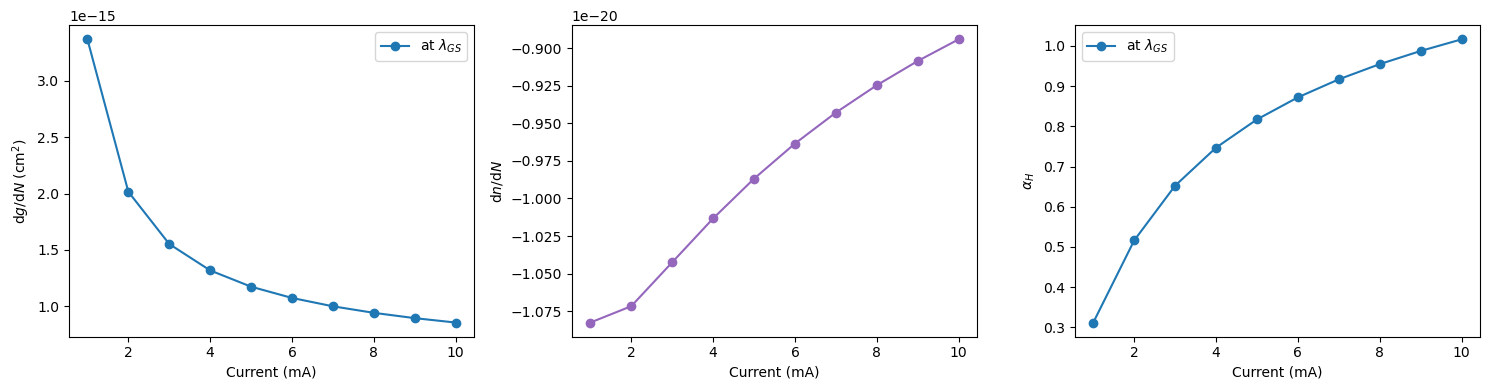

In [9]:
"""
Sweep of dg/dN, dn/dN and the linewidth enhancement factor (alpha_H) over
current, following the central-difference method used around J_thresh in
the original notebook, generalised to a run over 1-10 mA.

Run this in the SAME notebook / kernel session where the following are
already defined, since it relies on them and does not redefine them:
    - run_qd_simulation(...)
    - plot_gain_and_carriers(...)
    - refractive_index_change(...)
    - initial_values

Paste directly into a cell, or `%run alpha_factor_sweep.py` from the notebook.
"""

initial_values = {
    'n_e_sch' : 0.0,
    'n_e_w'   : 0.0,
    'n_e_im'  : np.zeros((n_m, N)),   # shape (n_m, N)
    'n_h_sch' : 0.0,
    'n_hq_qd' : 1e6,                 # initial hole population in QD reservoir
}

import os
import numpy as np
import matplotlib.pyplot as plt

# ── Configuration ─────────────────────────────────────────────────────────
output_dir = 'output_values'
len_omega  = 100                       # must match the simulation setting
os.makedirs(output_dir, exist_ok=True)

DEVICE_WIDTH_M  = 2.4e-6
DEVICE_LENGTH_M = 400e-6

# Add more entries here (e.g. 'ES': 1050.0) to reproduce both branches of
# Fig. 2(b) at once -- the loop below already handles any number of them.
TARGET_WAVELENGTHS_NM = {'GS': 1294.0}

PERTURB_FRAC = 0.01                    # +/-1% current step for the central difference
CONVERSION_FACTOR = 4019376.8605       # dg/dN unit-conversion constant fitted in the paper

I_bias_mA = np.linspace(1, 10, 10)     # 1, 2, ..., 10 mA


def current_mA_to_J(I_mA, width_m=DEVICE_WIDTH_M, length_m=DEVICE_LENGTH_M):
    """Same conversion used for J_thresh, generalised to any bias current."""
    return I_mA / (width_m * length_m * 1e3)


def load_or_run(J, **sim_kwargs):
    """Load a cached simulation result for a given J, or run + cache it."""
    filename = f"J_{J}.npz"
    filepath = os.path.join(output_dir, filename)
    if os.path.exists(filepath):
        data = np.load(filepath)
    else:
        _, final_state, _ = run_qd_simulation(J=J, **sim_kwargs)
        np.savez_compressed(filepath, **final_state)
        data = np.load(filepath)
    return {
        'n_e_sch': float(data['n_e_sch']),
        'n_e_w':   float(data['n_e_w']),
        'n_e_im':  data['n_e_im'],          # shape (3, 51): GS, ES1, ES2
        'n_h_sch': float(data['n_h_sch']),
        'n_hq_qd': float(data['n_hq_qd']),
    }


def total_carrier_density(state):
    """Sum every electron reservoir (SCH + WL + GS + ES1 + ES2) into one scalar."""
    return state['n_e_sch'] + state['n_e_w'] + np.sum(state['n_e_im'])


SIM_KWARGS = dict(
    t_end=100e-9,
    initial_values=initial_values,
    tstep=60e-15,
    threshold=0.05,
    verbose=False,
    params=None,
    m_h_w=0.4,
    m_e_w=0.026,
    delta_E_sch_w=75,
    delta_E_h_sch_w=140,
)

# ── Sweep over bias currents ────────────────────────────────────────────────
n_currents = len(I_bias_mA)

dgdN_spectrum = np.zeros((n_currents, len_omega))     # full dg/dN spectrum at each bias
wavelength_nm = None

dgdN_at_wavelength  = {label: np.zeros(n_currents) for label in TARGET_WAVELENGTHS_NM}
dndN                = np.zeros(n_currents)
alpha_at_wavelength = {label: np.zeros(n_currents) for label in TARGET_WAVELENGTHS_NM}

for i, I_mA in enumerate(I_bias_mA):
    print(f"I = {I_mA:.2f} mA")

    J_lower = current_mA_to_J(I_mA * (1 - PERTURB_FRAC))
    J_upper = current_mA_to_J(I_mA * (1 + PERTURB_FRAC))

    state_lower = load_or_run(J_lower, **SIM_KWARGS)
    state_upper = load_or_run(J_upper, **SIM_KWARGS)

    result_lower = plot_gain_and_carriers(state_lower, len_omega=len_omega)
    result_upper = plot_gain_and_carriers(state_upper, len_omega=len_omega)
    plt.close('all')   # suppress the per-call plots made inside plot_gain_and_carriers

    if wavelength_nm is None:
        wavelength_nm = result_lower['wavelength_nm']

    gain_lower = result_lower['gain_cm_minus_1']
    gain_upper = result_upper['gain_cm_minus_1']

    n_lower = refractive_index_change(state_lower['n_e_sch'], state_lower['n_e_w'],
                                       state_lower['n_e_im'], state_lower['n_h_sch'],
                                       state_lower['n_hq_qd'])
    n_upper = refractive_index_change(state_upper['n_e_sch'], state_upper['n_e_w'],
                                       state_upper['n_e_im'], state_upper['n_h_sch'],
                                       state_upper['n_hq_qd'])

    n_shift_lower = result_lower['n_shift'][35]
    n_shift_upper = result_upper['n_shift'][35]
    n_lower += n_shift_lower
    n_upper += n_shift_upper

    dN = total_carrier_density(state_upper) - total_carrier_density(state_lower)

    # dG/dN across the whole spectrum
    dgdN_spectrum[i] = CONVERSION_FACTOR * (gain_upper - gain_lower) / dN

    # dn/dN (single scalar, refractive_index_change is not wavelength-resolved)
    dndN[i] = (n_upper - n_lower) / dN

    # dg/dN and alpha_H at each requested wavelength
    for label, lam_nm in TARGET_WAVELENGTHS_NM.items():
        idx = np.argmin(np.abs(wavelength_nm - lam_nm))
        lam_cm = lam_nm * 1e-7
        dgdN_at_wavelength[label][i] = dgdN_spectrum[i, idx]
        alpha_at_wavelength[label][i] = (
            -4 * np.pi / lam_cm * dndN[i] / dgdN_at_wavelength[label][i]
        )

# ── Plot: dg/dN, dn/dN and alpha_H vs current, styled like Fig. 2(b) ────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for label in TARGET_WAVELENGTHS_NM:
    axes[0].plot(I_bias_mA, dgdN_at_wavelength[label], 'o-', label=f'at $\\lambda_{{{label}}}$')
axes[0].set_xlabel('Current (mA)')
axes[0].set_ylabel(r'd$g$/d$N$ (cm$^2$)')
axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axes[0].legend()

axes[1].plot(I_bias_mA, dndN, 'o-', color='tab:purple')
axes[1].set_xlabel('Current (mA)')
axes[1].set_ylabel(r'd$n$/d$N$')
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

for label in TARGET_WAVELENGTHS_NM:
    axes[2].plot(I_bias_mA, alpha_at_wavelength[label], 'o-', label=f'at $\\lambda_{{{label}}}$')
axes[2].set_xlabel('Current (mA)')
axes[2].set_ylabel(r'$\alpha_H$')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
rho_e_gs = / (params['N_l'] * params['N_D'] * G_i * D_m)

In [10]:
print(alpha_at_wavelength)

{'GS': array([0.31202612, 0.51632157, 0.65251105, 0.74711945, 0.81730101,
       0.87223152, 0.9170644 , 0.95487971, 0.98761914, 1.01656171])}


In [11]:
# ── Extend current range to comfortably cover 32 mA ─────────────────────────
I_bias_mA_full = np.arange(1, 36, 1)      # 1..35 mA
S_RE_VALUES = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
TARGET_LAMBDA_NM  = 1294.0
TARGET_CURRENT_MA = 32.0

# ── Step 1: get the steady state + resonant spectrum at every current, ONCE ─
states_by_current   = {}
n_shift_by_current   = {}   # resonant/dispersive term, full spectrum, per current
wavelength_nm_full    = None

for I_mA in I_bias_mA_full:
    J = current_mA_to_J(I_mA)
    state  = load_or_run(J, **SIM_KWARGS)
    result = plot_gain_and_carriers(state, len_omega=len_omega)
    plt.close('all')

    if wavelength_nm_full is None:
        wavelength_nm_full = result['wavelength_nm']

    states_by_current[I_mA]  = state
    n_shift_by_current[I_mA] = result['n_shift']   # shape (len_omega,)

lambda_idx = np.argmin(np.abs(wavelength_nm_full - TARGET_LAMBDA_NM))
print(f"Using wavelength index {lambda_idx} -> {wavelength_nm_full[lambda_idx]:.1f} nm")

# ── Plot A: effect of S_re on Δn vs current, at 1294 nm ─────────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))
for S_re in S_RE_VALUES:
    delta_n = np.zeros(len(I_bias_mA_full))
    for i, I_mA in enumerate(I_bias_mA_full):
        state = states_by_current[I_mA]
        drude_term = refractive_index_change(
            state['n_e_sch'], state['n_e_w'], state['n_e_im'],
            state['n_h_sch'], state['n_hq_qd'],
            S_re_e=S_re, S_re_h=S_re,
        )
        resonant_term = n_shift_by_current[I_mA][lambda_idx]
        delta_n[i] = drude_term + resonant_term
    ax.plot(I_bias_mA_full, delta_n, 'o-', label=f'$S_{{re}}$ = {S_re}')

ax.set_xlabel('Input current (mA)')
ax.set_ylabel(r'$\Delta n_{eff}$ at 1294 nm')
ax.legend(title='$S_{re}$')
ax.set_title(r'Effect of $S_{re}$ on $\Delta n_{eff}$ vs. current')
plt.tight_layout()
plt.show()

# ── Plot B: Drude vs. resonant contribution vs. wavelength, at 32 mA ────────
i_idx    = np.argmin(np.abs(I_bias_mA_full - TARGET_CURRENT_MA))
I_actual = I_bias_mA_full[i_idx]
print(f"Using I = {I_actual} mA (closest match to requested {TARGET_CURRENT_MA} mA)")

state_32mA = states_by_current[I_actual]
S_RE_DISPLAY = 1.0   # pick whichever S_re you want shown here

drude_32mA = refractive_index_change(
    state_32mA['n_e_sch'], state_32mA['n_e_w'], state_32mA['n_e_im'],
    state_32mA['n_h_sch'], state_32mA['n_hq_qd'],
    S_re_e=S_RE_DISPLAY, S_re_h=S_RE_DISPLAY,
)
resonant_32mA = n_shift_by_current[I_actual]   # full spectrum, shape (len_omega,)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(wavelength_nm_full, resonant_32mA, label='Resonant (dispersive, QD susceptibility)')
ax.axhline(drude_32mA, color='k', linestyle='--', label='Drude (free-carrier, flat)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$\Delta n$ contribution')
ax.legend()
ax.set_title(f'Drude vs. resonant $\\Delta n$ at I = {I_actual:.0f} mA, $S_{{re}}$ = {S_RE_DISPLAY}')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
print(dndN*dN)
print(n_upper)
print(n_lower)

[-6.66583866e-06 -6.97399835e-06 -7.21066927e-06 -7.44776292e-06
 -7.69937234e-06 -7.96916386e-06 -8.25801362e-06 -8.56587908e-06
 -8.89237849e-06 -9.23698660e-06]
-0.0008533379218848933
-0.000844100935287797
